In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr
import matplotlib.dates as mdates

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity, out_core_param_fit


In [2]:
def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
    from scipy.optimize import least_squares
    def nan_return():
        nan2 = np.full((2, 2), np.nan)
        coeffs = pd.DataFrame(
            np.nan,
            index=['0', '1', '2', '3'],
            columns=['A', 'B', 'C', 'D']
        )
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan
        # return {
        #     'xc': np.nan,
        #     'yc': np.nan,
        #     'Omega': np.nan,
        #     'Q': nan2,
        #     'x0': np.nan,
        #     'y0': np.nan,
        #     'A': np.full(4, np.nan),
        #     'B': np.full(4, np.nan),
        #     'C': np.full(4, np.nan),
        #     'D': np.full(4, np.nan),
        #     'a0': np.nan, 'a1': np.nan,
        #     'b0': np.nan, 'b1': np.nan,
        #     'c0': np.nan, 'c1': np.nan,
        #     'd0': np.nan, 'd1': np.nan,
        #     'coeffs': coeffs,
        #     'success': False
        # }

    def clean(*arrs):
        arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
        m = np.logical_and.reduce([np.isfinite(a) for a in arrs])
        return [a[m] for a in arrs]

    def poly3(p, z):
        return p[0] + p[1]*z + p[2]*z**2 + p[3]*z**3

    def find_root(x, y, degree=3):
        if x.size < degree + 1:
            return np.nan

        try:
            coeffs = np.polyfit(x, y, degree)
            roots = np.roots(coeffs)
        except Exception:
            return np.nan

        real_roots = roots[np.isreal(roots)].real
        if real_roots.size == 0:
            return np.nan

        mid_x = np.median(x)
        return real_roots[np.argmin(np.abs(real_roots - mid_x))]

    x1, y1, u1, v1 = clean(x1, y1, u1, v1)
    x2, y2, u2, v2 = clean(x2, y2, u2, v2)

    if len(x1) < 4 or len(y2) < 4:
        return nan_return()

    pts1 = np.column_stack((x1, y1))
    pts2 = np.column_stack((x2, y2))

    common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

    if len(common) != 1:
        return nan_return()

    center_x, center_y = common[0]

    # Set origin at transect center
    x = x1 - center_x
    y = y2 - center_y

    # Initial guesses
    # Unconstrained cubic fits used only to estimate x0 and y0
    x0_guess = find_root(x, v1)
    y0_guess = find_root(y, u2)

    # x0_guess = x[np.argmin(np.abs(v1))] if len(x) else 0.0
    # y0_guess = y[np.argmin(np.abs(u2))] if len(y) else 0.0

    pA = np.polyfit(x, u1, 3)[::-1]
    pB = np.polyfit(x, v1, 3)[::-1]
    pC = np.polyfit(y, u2, 3)[::-1]
    pD = np.polyfit(y, v2, 3)[::-1]

    # Free parameters:
    # x0, y0,
    # A0,A1,A2,A3,
    # B1,B2,B3,   with B0 set so V1(x0)=0 exactly
    # C1,C2,C3,   with C0 set so U2(y0)=0 exactly
    # D0,D2,D3,   with D1 set so d1=-a1 exactly
    p0 = np.array([
        x0_guess, y0_guess,
        pA[0], pA[1], pA[2], pA[3],
        pB[1], pB[2], pB[3],
        pC[1], pC[2], pC[3],
        pD[0], pD[2], pD[3]
    ], dtype=float)

    def unpack(p):
        x0, y0 = p[0], p[1]

        A0, A1, A2, A3 = p[2:6]
        B1, B2, B3 = p[6:9]
        C1, C2, C3 = p[9:12]
        D0, D2, D3 = p[12:15]

        a1 = A1 + 2*A2*x0 + 3*A3*x0**2
        b1 = B1 + 2*B2*x0 + 3*B3*x0**2
        c1 = C1 + 2*C2*y0 + 3*C3*y0**2

        B0 = -x0 * b1 # V1(x0)=0 
        C0 = -y0 * c1 # U2(y0)=0 
        D1 = -a1 - 2*D2*y0 - 3*D3*y0**2 # d1=-a1

        A = np.array([A0, A1, A2, A3], dtype=float)
        B = np.array([B0, B1, B2, B3], dtype=float)
        C = np.array([C0, C1, C2, C3], dtype=float)
        D = np.array([D0, D1, D2, D3], dtype=float)

        return x0, y0, A, B, C, D

    def residuals(p):
        x0, y0, A, B, C, D = unpack(p)

        U1 = poly3(A, x)
        V1 = poly3(B, x)
        U2 = poly3(C, y)
        V2 = poly3(D, y)

        return np.r_[U1 - u1, V1 - v1, U2 - u2, V2 - v2]

    res = least_squares(residuals, p0, method='trf')

    if not res.success:
        return nan_return()

    x0, y0, A, B, C, D = unpack(res.x)

    A0, A1, A2, A3 = A
    B0, B1, B2, B3 = B
    C0, C1, C2, C3 = C
    D0, D1, D2, D3 = D

    # Tangent coefficients
    a1 = A1 + 2*A2*x0 + 3*A3*x0**2
    a0 = (A0 + A1*x0 + A2*x0**2 + A3*x0**3) - x0*a1

    b1 = B1 + 2*B2*x0 + 3*B3*x0**2
    b0 = -x0*b1

    c1 = C1 + 2*C2*y0 + 3*C3*y0**2
    c0 = -y0*c1

    d1 = D1 + 2*D2*y0 + 3*D3*y0**2
    d0 = (D0 + D1*y0 + D2*y0**2 + D3*y0**3) - y0*d1

    # Enforce d1 = -a1 numerically if tiny mismatch remains
    d1 = -a1

    radicand = -b1*c1 - a1**2
    if radicand <= 0 or not np.isfinite(radicand):
        return nan_return()

    Omega = np.sign(b1) * np.sqrt(radicand)
    if Omega == 0 or not np.isfinite(Omega):
        return nan_return()

    Q = (1 / Omega) * np.array([
        [b1,  -a1],
        [-a1, -c1]
    ], dtype=float)

    xc = (a0*a1 + c1*d0) / Omega**2
    yc = (a0*b1 - a1*d0) / Omega**2

    w = Omega * (Q[0,0] + Q[1,1])

    coeffs = pd.DataFrame(
        {
            'A': A,
            'B': B,
            'C': C,
            'D': D
        },
        index=['0', '1', '2', '3']
    )

    

    # return {
    #     'xc': xc,
    #     'yc': yc,
    #     'Omega': Omega,
    #     'Q': Q,
    #     'x0': x0,
    #     'y0': y0,
    #     'A': A,
    #     'B': B,
    #     'C': C,
    #     'D': D,
    #     'a0': a0, 'a1': a1,
    #     'b0': b0, 'b1': b1,
    #     'c0': c0, 'c1': c1,
    #     'd0': d0, 'd1': d1,
    #     'coeffs': coeffs,
    #     'success': True
    # }

    yu1 = a0 + a1*x
    yv1 = b0 + b1*x
    yu2 = c0 + c1*y
    yv2 = d0 + d1*y

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(8, 6))

        xs = np.linspace(x.min(), x.max(), 400)
        ys = np.linspace(y.min(), y.max(), 400)

        U1s = poly3(A, xs)
        V1s = poly3(B, xs)
        U2s = poly3(C, ys)
        V2s = poly3(D, ys)

        axs[0, 0].scatter(x, u1, s=10)
        axs[0, 0].plot(xs, U1s)
        axs[0, 0].plot(x, yu1)
        axs[0, 0].axvline(x0, ls='--')
        axs[0, 0].set_title("U1(x)")

        axs[0, 1].scatter(x, v1, s=10)
        axs[0, 1].plot(xs, V1s)
        axs[0, 1].plot(x, yv1)
        axs[0, 1].axvline(x0, ls='--')
        axs[0, 1].axhline(0, ls='--')
        axs[0, 1].set_title("V1(x)")

        axs[1, 0].scatter(y, u2, s=10)
        axs[1, 0].plot(ys, U2s)
        axs[1, 0].plot(y, yu2)
        axs[1, 0].axvline(y0, ls='--')
        axs[1, 0].axhline(0, ls='--')
        axs[1, 0].set_title("U2(y)")

        axs[1, 1].scatter(y, v2, s=10)
        axs[1, 1].plot(ys, V2s)
        axs[1, 1].plot(y, yv2)
        axs[1, 1].axvline(y0, ls='--')
        axs[1, 1].set_title("V2(y)")

        plt.tight_layout()
        plt.show()

    return xc + center_x, yc + center_y, w, Q, Omega
    

In [3]:
def doppio_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

### Numerical Data

In [4]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_copernicus_CCE_2023_1D.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['longitude'][:], ds_nc['latitude'][:]
u = np.squeeze(ds_nc['uo'][:]); v = np.squeeze(ds_nc['vo'][:])
# u, v = np.transpose(u, (2,1,0)), np.transpose(v, (2,1,0))  # (time, lat, lon)
t = pd.Timestamp("1950-01-01") + pd.to_timedelta(ds_nc['time'][:], "h")
u, v = np.where(np.abs(u) < 100, u, np.nan), np.where(np.abs(v) < 100, v, np.nan)
lon2d, lat2d = np.meshgrid(lon, lat, indexing="xy")
theta_mean, phi_mean = 154.3, -37.9
x = (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
y = (lat2d-phi_mean)*111000
ds_cop = xr.Dataset(
    {"u": (("time","lat","lon"), u),
     "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon,
            "x": (("lat","lon"), x),
            "y": (("lat","lon"), y)}
)
ds_cop["land_mask"] = np.isnan(ds_cop.u.isel(time=0)) & np.isnan(ds_cop.v.isel(time=0))
# # Time slice
ds_cop = ds_cop.sel(time=ds_cop.time <= np.datetime64('2024-01-27T00:00:00.000000000'))

print(ds_cop.time.min(), ds_cop.time.max())
print(ds_cop.lat.min(), ds_cop.lat.max())
print(ds_cop.lon.min(), ds_cop.lon.max())

ds_cop


<xarray.DataArray 'time' ()> Size: 8B
array('2023-10-19T00:00:00.000000000', dtype='datetime64[ns]') <xarray.DataArray 'time' ()> Size: 8B
array('2024-01-27T00:00:00.000000000', dtype='datetime64[ns]')
<xarray.DataArray 'lat' ()> Size: 4B
array(-42., dtype=float32) <xarray.DataArray 'lat' ()> Size: 4B
array(-34., dtype=float32)
<xarray.DataArray 'lon' ()> Size: 4B
array(149., dtype=float32) <xarray.DataArray 'lon' ()> Size: 4B
array(158., dtype=float32)


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 101, lat: 97, lon: 109)
Coordinates:
  * time       (time) datetime64[ns] 808B 2023-10-19 ... 2024-01-27
  * lat        (lat) float32 388B -42.0 -41.92 -41.83 ... -34.17 -34.08 -34.0
  * lon        (lon) float32 436B 149.0 149.1 149.2 149.2 ... 157.8 157.9 158.0
    x          (lat, lon) float64 85kB -4.642e+05 -4.569e+05 ... 3.241e+05
    y          (lat, lon) float64 85kB -4.551e+05 -4.551e+05 ... 4.329e+05
Data variables:
    u          (time, lat, lon) float32 4MB -0.284 -0.3366 ... 0.3254 0.346
    v          (time, lat, lon) float32 4MB -0.2342 -0.1941 ... -0.1586 -0.1242
    land_mask  (lat, lon) bool 11kB False False False ... False False False

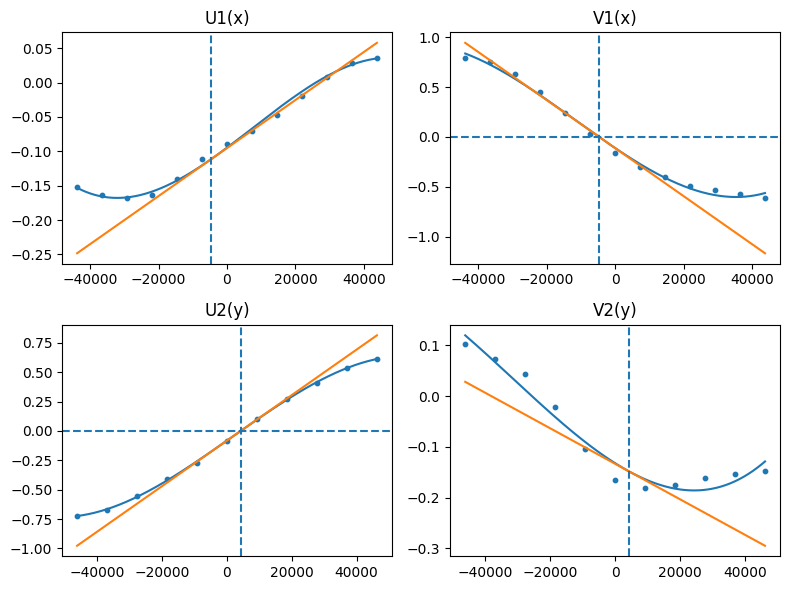

,xc,yc,w,Q,Omega,time,alpha
0,-5125.095355,-797.697475,-0.000040,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000020,2023-10-19 00:00:00,1.100561
1,-3471.649313,291.793634,-0.000041,"[[0.9685311171766586, -0.09217048259706591], [...",-0.000020,2023-10-19 23:56:15,1.103982
2,-7756.218779,-5434.595588,-0.000041,"[[0.92486914104395, -0.11936775324512824], [-0...",-0.000020,2023-10-21 00:00:00,1.157809
3,-3099.643663,-4604.936556,-0.000042,"[[0.8962093241916665, -0.12740320203928893], [...",-0.000021,2023-10-22 00:00:00,1.189302
4,-628.950631,-4833.080558,-0.000041,"[[0.8196407793344359, -0.056223671837836185], ...",-0.000020,2023-10-22 23:56:15,1.231577
...,...,...,...,...,...,...,...
96,-251761.221804,167749.846372,-0.000026,"[[1.194097564291838, 0.013789833203115873], [0...",-0.000013,2024-01-23 00:00:00,1.194630
97,-254769.682875,162518.463332,-0.000018,"[[1.5074853843445863, -0.21726772870890168], [...",-0.000008,2024-01-24 00:00:00,1.561917
98,-270172.123673,154268.416478,-0.000017,"[[1.2728191361593584, -0.45121890347086907], [...",-0.000008,2024-01-25 00:00:00,1.589180
99,-261663.662651,166086.561707,-0.000017,"[[1.230046502322559, -0.4985208332297986], [-0...",-0.000008,2024-01-26 00:00:00,1.632516


In [5]:
xc_pre, yc_pre = 0.0, 0.0
rows = []
xyuv_rows = []

X = ds_cop.x.values
Y = ds_cop.y.values

for t, time in enumerate(ds_cop.time.values):
    ut = ds_cop.u.sel(time=time).values
    vt = ds_cop.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = doppio_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, Omega = doppio(x1,y1,u1,v1,x2,y2,u2,v2, plot=True if t == 10 else False)

    ok = (np.isfinite(xc) and np.isfinite(yc) and
          (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0))

    if not ok:
        break

    rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, Omega=Omega, time=time))
    xc_pre, yc_pre = xc, yc

    xi = np.concatenate([x1, x2])
    yi = np.concatenate([y1, y2])
    ui = np.concatenate([u1, u2])
    vi = np.concatenate([v1, v2])

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi, "yi": yi, "ui": ui, "vi": vi
    }))

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","Omega","time"])
df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]

df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_res


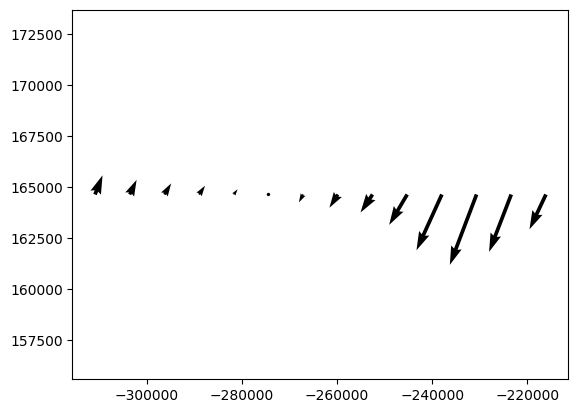

In [6]:
plt.quiver(x1,y1,u1,v1)

(np.float64(-284051.3909558343),
 np.float64(13571.6141966008),
 np.float64(-18553.85188805307),
 np.float64(192106.95530106785))

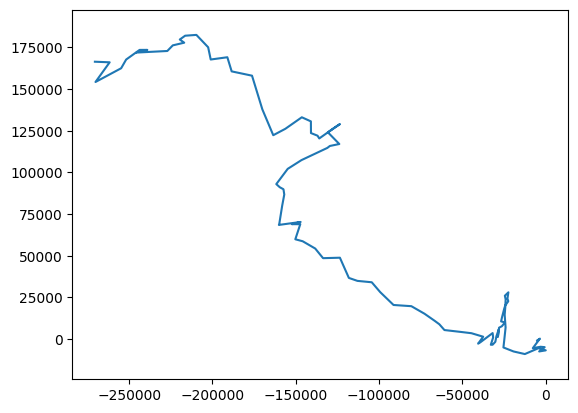

In [7]:
plt.plot(df_res.xc, df_res.yc)
plt.axis('equal')


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0
0,-5125.095355,-797.697475,-0.000036,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000018,2023-10-19 00:00:00,1.100561,84171.005790,63147.724492
1,-3471.649313,291.793634,-0.000036,"[[0.9685311171766586, -0.09217048259706591], [...",-0.000018,2023-10-19 23:56:15,1.103982,83629.253525,62598.430569
2,-7756.218779,-5434.595588,-0.000036,"[[0.92486914104395, -0.11936775324512824], [-0...",-0.000018,2023-10-21 00:00:00,1.157809,84719.695637,63222.726354
3,-3099.643663,-4604.936556,-0.000037,"[[0.8962093241916665, -0.12740320203928893], [...",-0.000018,2023-10-22 00:00:00,1.189302,83102.655997,62914.481172
4,-628.950631,-4833.080558,-0.000037,"[[0.8196407793344359, -0.056223671837836185], ...",-0.000018,2023-10-22 23:56:15,1.231577,82764.124371,62456.381429
...,...,...,...,...,...,...,...,...,...
96,-251761.221804,167749.846372,-0.000035,"[[1.194097564291838, 0.013789833203115873], [0...",-0.000017,2024-01-23 00:00:00,1.194630,62132.835963,33044.661077
97,-254769.682875,162518.463332,-0.000033,"[[1.5074853843445863, -0.21726772870890168], [...",-0.000015,2024-01-24 00:00:00,1.561917,65992.369407,32417.778191
98,-270172.123673,154268.416478,-0.000028,"[[1.2728191361593584, -0.45121890347086907], [...",-0.000013,2024-01-25 00:00:00,1.589180,71211.892855,32145.920158
99,-261663.662651,166086.561707,-0.000023,"[[1.230046502322559, -0.4985208332297986], [-0...",-0.000010,2024-01-26 00:00:00,1.632516,79683.435650,31916.538717


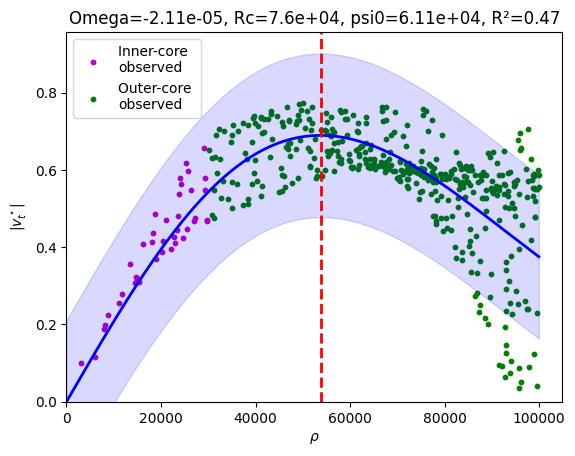

In [8]:
rho_outer = 100_000.0

xi0 = ds_cop.x.values.ravel()
yi0 = ds_cop.y.values.ravel()

Rc_opts, psi0_opts, Omega_opts = [], [], []
xyuv_rows = []

for k, data in df_res.iterrows():
    time = data.time

    ui0 = ds_cop.u.sel(time=time).values.ravel()
    vi0 = ds_cop.v.sel(time=time).values.ravel()

    xc, yc = float(data.xc), float(data.yc)
    Q = np.asarray(data.Q)
    Omega = float(data.Omega)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi0 - xc
    dy = yi0 - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o = xi0[outer], yi0[outer]
    ui_o, vi_o = ui0[outer], vi0[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((q11*dx_o + q12*dy_o)**2 + (q12*dx_o + q22*dy_o)**2)

    sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega, plot=(k == 10), pred_flag=True)
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); Omega_opts.append(Omega_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)
df_xyuv = (
    df_xyuv
    .sort_values(by="core", key=lambda s: s.eq("outer"))  # keep inner first
    .drop_duplicates(subset=["time", "xi", "yi", "ui", "vi"], keep="first")
    .reset_index(drop=True)
)

df_res["Rc"] = Rc_opts
df_res["psi0"] = psi0_opts
df_res["Omega"] = Omega_opts
df_res["w"] = [Omega*(Q[0,0] + Q[1,1]) for (Omega,Q) in zip(df_res.Omega, df_res.Q)]
df_res


In [9]:
df_xyuv

,time,core,xi,yi,ui,vi
0,2023-10-19,inner,-48173.583379,-1849.717712,0.081730,0.551423
1,2023-12-25,inner,-172256.164725,99900.000000,0.095455,0.172887
2,2023-12-25,inner,-164956.245945,99900.000000,0.034228,0.085946
3,2023-12-25,inner,-157659.000150,99900.000000,-0.032171,-0.000519
4,2023-12-25,inner,-150359.081371,99900.000000,-0.103882,-0.069451
...,...,...,...,...,...,...
47007,2023-11-21,outer,-26276.500025,35150.141144,0.520040,0.012456
47008,2023-11-21,outer,-18976.581246,35150.141144,0.475213,-0.161726
47009,2023-11-21,outer,-11676.662466,35150.141144,0.419602,-0.318968
47010,2023-11-21,outer,2920.502108,35150.141144,0.300488,-0.527960


In [10]:
df = df_xyuv.copy()

xg = ds_cop.x[0, :].values
yg = ds_cop.y[:, 0].values

xi = df["xi"].to_numpy()
yi = df["yi"].to_numpy()

i = np.searchsorted(xg, xi)
i = np.clip(i, 1, len(xg) - 1)
i -= (xi - xg[i - 1] < xg[i] - xi)

j = np.searchsorted(yg, yi)
j = np.clip(j, 1, len(yg) - 1)
j -= (yi - yg[j - 1] < yg[j] - yi)

df["i"] = i
df["j"] = j

df_xyuv = df


In [11]:
# Find R2
def model_uv_at_xy(xi, yi, xc, yc, Q, Omega, Rc):
    dx = xi - xc
    dy = yi - yc

    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    fac = Omega * np.exp(-rho2 / (Rc*Rc))

    uhat = -fac * (q12*dx + q22*dy)
    vhat =  fac * (q11*dx + q12*dy)

    return uhat, vhat
    
def vector_R2(u, v, uhat, vhat):
    m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
    if not np.any(m):
        return np.nan
    u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
    err2 = (uhat - u)**2 + (vhat - v)**2
    u0, v0 = np.mean(u), np.mean(v)
    tot2 = (u - u0)**2 + (v - v0)**2
    return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan

R2_vals = []
for _, row in df_res.iterrows():
    df = df_xyuv[df_xyuv.time == row.time]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))
df_res['R2'] = R2_vals
df_res


,xc,yc,w,Q,Omega,time,alpha,Rc,psi0,R2
0,-5125.095355,-797.697475,-0.000036,"[[1.0292421327325185, -0.09274719301104836], [...",-0.000018,2023-10-19 00:00:00,1.100561,84171.005790,63147.724492,0.941040
1,-3471.649313,291.793634,-0.000036,"[[0.9685311171766586, -0.09217048259706591], [...",-0.000018,2023-10-19 23:56:15,1.103982,83629.253525,62598.430569,0.953327
2,-7756.218779,-5434.595588,-0.000036,"[[0.92486914104395, -0.11936775324512824], [-0...",-0.000018,2023-10-21 00:00:00,1.157809,84719.695637,63222.726354,0.922006
3,-3099.643663,-4604.936556,-0.000037,"[[0.8962093241916665, -0.12740320203928893], [...",-0.000018,2023-10-22 00:00:00,1.189302,83102.655997,62914.481172,0.950188
4,-628.950631,-4833.080558,-0.000037,"[[0.8196407793344359, -0.056223671837836185], ...",-0.000018,2023-10-22 23:56:15,1.231577,82764.124371,62456.381429,0.954496
...,...,...,...,...,...,...,...,...,...,...
96,-251761.221804,167749.846372,-0.000035,"[[1.194097564291838, 0.013789833203115873], [0...",-0.000017,2024-01-23 00:00:00,1.194630,62132.835963,33044.661077,0.409838
97,-254769.682875,162518.463332,-0.000033,"[[1.5074853843445863, -0.21726772870890168], [...",-0.000015,2024-01-24 00:00:00,1.561917,65992.369407,32417.778191,0.518784
98,-270172.123673,154268.416478,-0.000028,"[[1.2728191361593584, -0.45121890347086907], [...",-0.000013,2024-01-25 00:00:00,1.589180,71211.892855,32145.920158,0.372785
99,-261663.662651,166086.561707,-0.000023,"[[1.230046502322559, -0.4985208332297986], [-0...",-0.000010,2024-01-26 00:00:00,1.632516,79683.435650,31916.538717,0.437447


In [12]:
X = ds_cop.x.values
Y = ds_cop.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (q12*dx + q22*dy)
    V[k] =  fac * (q11*dx + q12*dy)

mask = ds_cop.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_cop.lat.values,
        lon=ds_cop.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)


In [13]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates

def plot__model(df_res, ds_cop, ds_model, df_xyuv, time=None, spac=1, scale=20,
                xlim=(-410, 200), ylim=(-160, 260), out_thresh=False, plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_cop.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmax = np.nanmax(vals)
    levels = np.arange(0, vmax + .05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100),
                               np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[0,1]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True, constrained_layout=True)

    # ----- coloured center path -----
    x_path = df_res.xc.to_numpy() / 1e3
    y_path = df_res.yc.to_numpy() / 1e3
    t_path = pd.to_datetime(df_res.time)
    t_num = mdates.date2num(t_path)

    pts = np.array([x_path, y_path]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    norm_t = Normalize(t_num.min(), t_num.max())
    lc0 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc0.set_array(t_num[:-1])

    lc1 = LineCollection(segs, cmap="plasma", norm=norm_t, linewidth=2, zorder=2)
    lc1.set_array(t_num[:-1])

    # ---- Numerical model ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.4)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, zorder=3)
    axs[0].add_collection(lc0)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    if plot_data:
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'outer')]
        # axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color='g', label='Outer-core data', zorder=1)

        ni, nj = X.shape
        
        U = np.full((ni, nj), np.nan)
        V = np.full((ni, nj), np.nan)
        
        # fill grid
        U[df["j"], df["i"]] = df["ui"].values
        V[df["j"], df["i"]] = df["vi"].values
        
        axs[0].quiver(
            X[::spac, ::spac],
            Y[::spac, ::spac],
            U[::spac, ::spac],
            V[::spac, ::spac],
            scale=scale,
            width=.0025,
            color='g',
            label='Outer-core data',
            zorder=2
        )
        
        df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == 'inner')]
        # print(df)
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi,
                      scale=scale, width=.0025, color='m', label='Transect/inner-core data', zorder=3)

    # axs[0].set_title("Numerical Model")
    axs[0].set_aspect("equal")
    axs[0].legend(loc='lower left')

    # ---- Fitted model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center', zorder=3)
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity', ls='--')
    axs[1].add_collection(lc1)
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles='--', zorder=3)

    # axs[1].set_title("Model - DOPPIO with Numerical Data")
    axs[1].set_aspect("equal")
    axs[1].legend(loc='lower left')

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
        ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    # speed colourbar
    cbar1 = fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)

    # time colourbar on far right
    cbar2 = fig.colorbar(lc1, ax=axs, fraction=0.0165, pad=0.025)
    cbar2.set_label("Center path time")
    cbar2.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

    print(time)
    plt.show()


2023-10-22T00:00:00.000000000


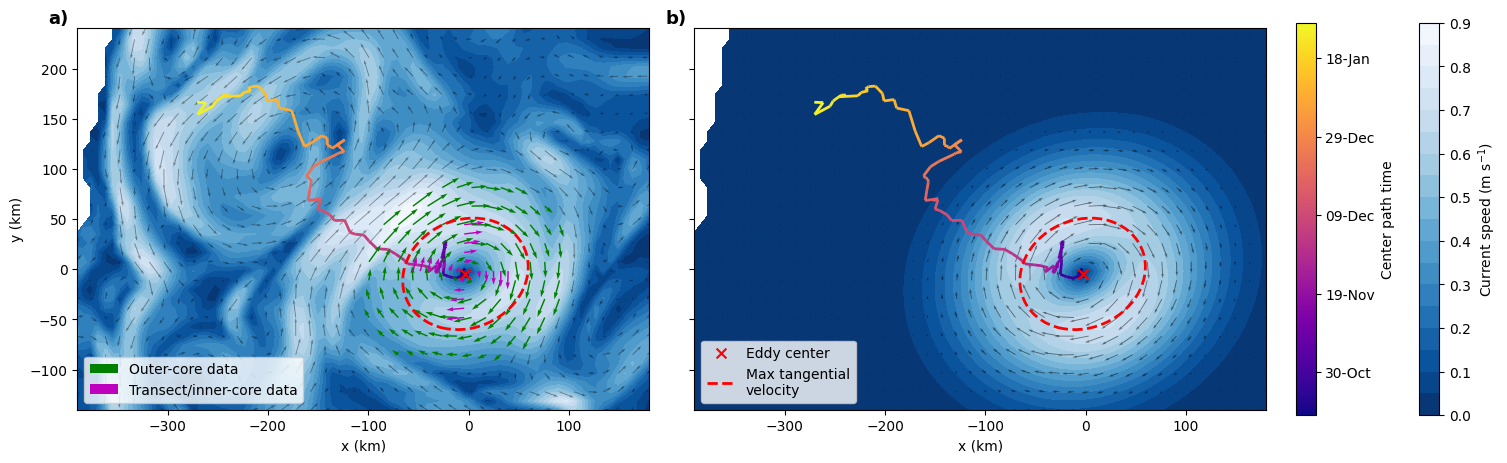

In [14]:
plot__model(df_res, ds_cop, ds_model, df_xyuv, time=df_res.time.values[3], spac=2, out_thresh=False, plot_data=True)


### Time series plot

In [ ]:
X = ds_cop.x.values
Y = ds_cop.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (q12*dx + q22*dy)
    V[k] =  fac * (q11*dx + q12*dy)

mask = ds_cop.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_cop.lat.values,
        lon=ds_cop.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)




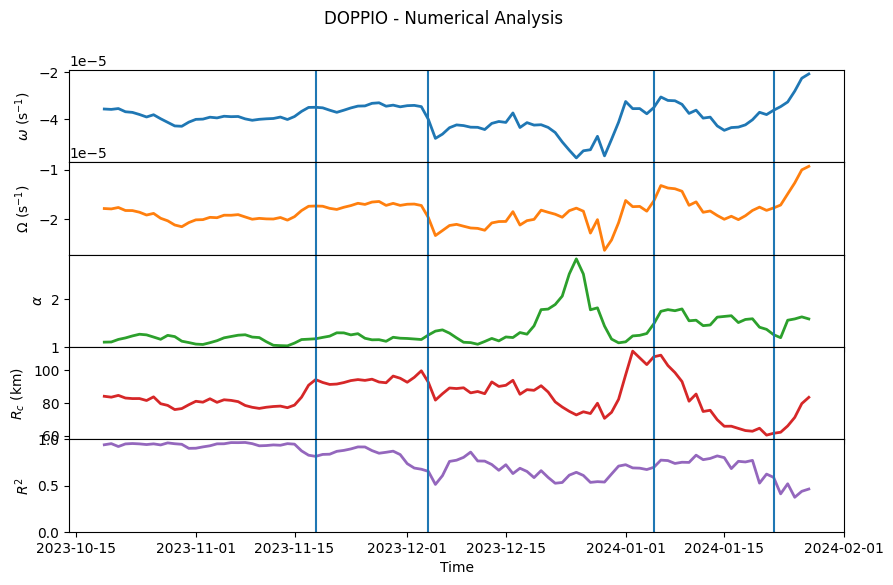

In [356]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')

axs[1].plot(df_res.time, df_res.Omega, color=clrs(1), lw=lw)
axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')

axs[2].plot(df_res.time, df_res.alpha, color=clrs(2), lw=lw)
axs[2].set_ylabel(r'$\alpha$')
axs[2].set_ylim(1, None)

axs[3].plot(df_res.time, df_res.Rc/1e3, color=clrs(3), lw=lw)
axs[3].set_ylabel(r'$R_c$ (km)')

axs[4].plot(df_res.time, df_res.R2, color=clrs(4), lw=lw)
axs[4].set_ylabel(r'$R^2$')
axs[4].set_xlabel('Time')
axs[4].set_ylim(0,1)

# tstamps = [10, 30, 47, 70, 99]
# tstamps = [30, 46, 67, 99]
           
for ax in axs:
    for t in tstamps:
        ax.axvline(df_res.time.iloc[t])

fig.suptitle("DOPPIO - Numerical Analysis")
fig.subplots_adjust(hspace=0)


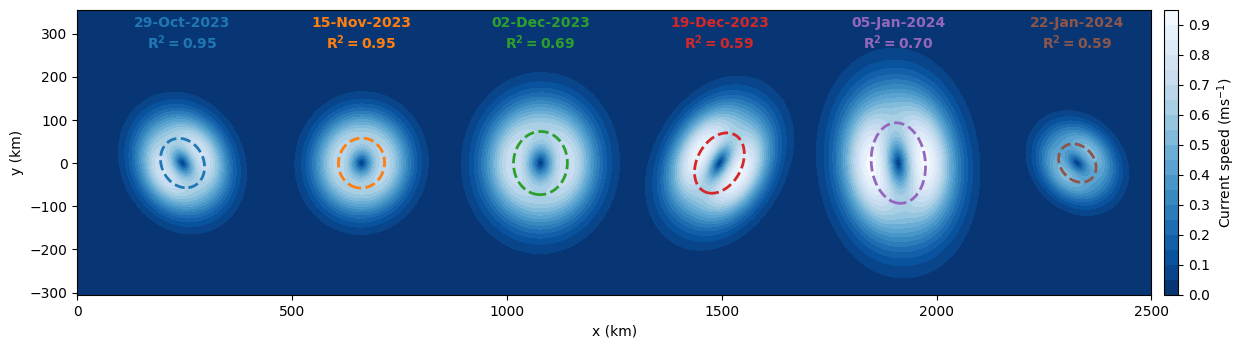

In [245]:
spac = 1_000
x = np.arange(0, 2_500_000 + spac, spac)
y = np.arange(-305_000, 355_000 + spac, spac)
X, Y = np.meshgrid(x, y)

# tstamps = [10, 30, 47, 63, 79, 95]
tstamps = np.arange(10, 100, 17)
inds = tstamps
clrs = plt.colormaps['tab10']

fig, ax = plt.subplots(figsize=(16.5, 3.7))

spd = np.zeros(X.shape, dtype=float)

xticks = []
xticklabels = []

for k, i in enumerate(inds):
    data = df_res.iloc[i]
    t0 = pd.Timestamp(data.time)

    # eddy centre location in x (km)
    xc = i * 24.5e3
    xticks.append(xc / 1e3)
    xticklabels.append(t0.strftime('%d-%b'))

    dx = X - xc
    dy = Y

    q11, q12, q22 = data.Q[0, 0], data.Q[0, 1], data.Q[1, 1]

    rho2 = q11 * dx**2 + 2 * q12 * dx * dy + q22 * dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U = -fac * (q12 * dx + q22 * dy)
    V =  fac * (q11 * dx + q12 * dy)

    ax.contour(
        X/1e3, Y/1e3,
        rho2/1e6,
        levels=[((data.Rc/1e3)**2)/2],
        colors=clrs(k),
        linewidths=2,
        linestyles='--',
        zorder=3
    )

    ax.text(
        xc / 1e3, 300,
        f"{t0.strftime('%d-%b-%Y')}\n$\\mathbf{{R^2 = {data.R2:.2f}}}$",
        color=clrs(k),
        ha='center',
        va='center',
        fontweight='bold'
    )

    spd += np.hypot(U, V)

# --- main field ---
levels = np.arange(0, np.nanmax(spd) + .05, .05)
cf = ax.contourf(X / 1e3, Y / 1e3, spd, levels=levels, cmap='Blues_r')

plt.colorbar(cf, ax=ax, label='Current speed (ms$^{-1}$)', pad=0.01)

# --- bottom axis: distance ---
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')

ax.axis('equal')

plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


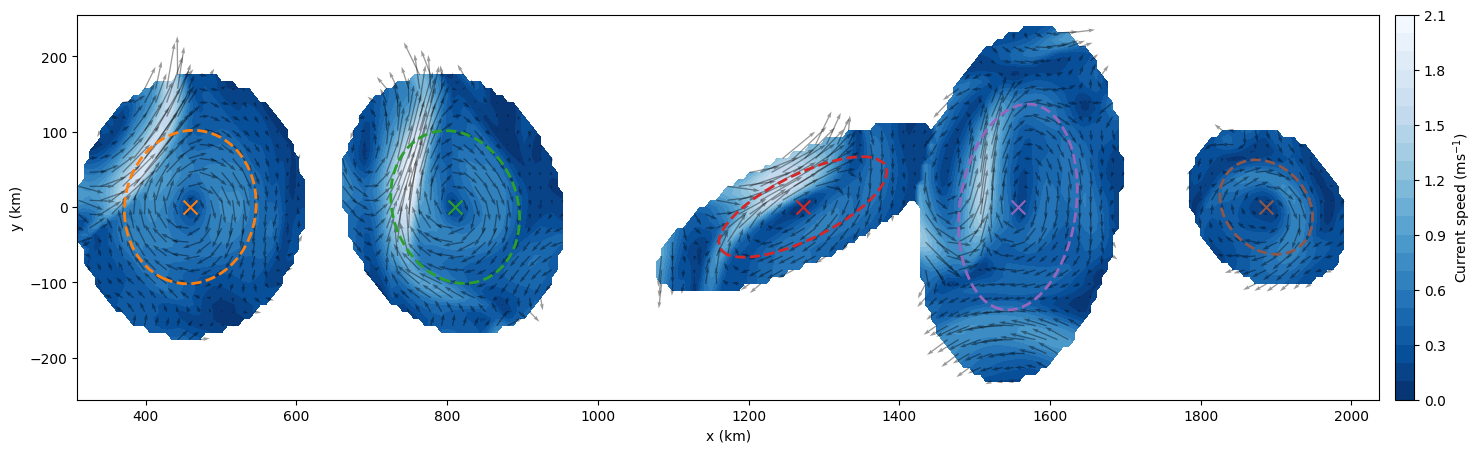

In [364]:
# base grid in km
Xg = cop.x.values / 1e3
Yg = cop.y.values / 1e3


tstamps = [30, 46, 67, 80, 95]
ks = tstamps
rho_outer_thresh = 180  # km

ny, nx = Xg.shape

dx_big = np.diff(Xg, axis=1).mean()
dy_big = np.diff(Yg, axis=0).mean()

x_big = np.arange(-200, 2000, dx_big)
y_big = np.arange(-250, 250, dy_big)

X_big, Y_big = np.meshgrid(x_big, y_big)

U_big = np.full(X_big.shape, np.nan)
V_big = np.full(X_big.shape, np.nan)

# x_offsets = x_big[round(np.array(tstamps)/len(df_res)*len(x_big))] # np.arange(len(ks)) * 350
frac = np.array(tstamps) / (len(df_res) - 1)
x_offsets = x_big.min() + frac * (x_big.max() - x_big.min())
y_offset = 0

fig, ax = plt.subplots(figsize=(20, 5))
clrs = plt.colormaps['tab10']
for j, k in enumerate(ks):
    data = df_res.iloc[k]
    cop = ds_cop.sel(time=data.time, method="nearest")

    uc = cop.u.values
    vc = cop.v.values

    dx = Xg - data.xc / 1e3
    dy = Yg - data.yc / 1e3

    q11, q12, q22 = data.Q[0, 0], data.Q[0, 1], data.Q[1, 1]
    rho2 = q11 * dx**2 + 2 * q12 * dx * dy + q22 * dy**2

    # mask = rho2 <= rho_outer_thresh**2
    mask = rho2 <= (data.Rc/1e3*1.75)**2

    um = np.where(mask, uc, np.nan)
    vm = np.where(mask, vc, np.nan)

    R_grid = np.hypot(Xg - data.xc / 1e3, Yg - data.yc / 1e3)
    ic, jc = np.unravel_index(np.nanargmin(R_grid), R_grid.shape)

    xc_target = x_offsets[j]
    yc_target = y_offset

    R_big = np.hypot(X_big - xc_target, Y_big - yc_target)
    ib, jb = np.unravel_index(np.nanargmin(R_big), R_big.shape)

    i0 = ib - ic
    i1 = i0 + ny
    j0 = jb - jc
    j1 = j0 + nx

    si0 = max(0, i0)
    sj0 = max(0, j0)
    si1 = min(U_big.shape[0], i1)
    sj1 = min(U_big.shape[1], j1)

    ui0 = si0 - i0
    uj0 = sj0 - j0
    ui1 = ui0 + (si1 - si0)
    uj1 = uj0 + (sj1 - sj0)

    U_sub = U_big[si0:si1, sj0:sj1]
    V_sub = V_big[si0:si1, sj0:sj1]

    u_new = um[ui0:ui1, uj0:uj1]
    v_new = vm[ui0:ui1, uj0:uj1]

    mask_new = np.isfinite(u_new) & np.isfinite(v_new)

    U_sub[mask_new] = u_new[mask_new]
    V_sub[mask_new] = v_new[mask_new]

    U_big[si0:si1, sj0:sj1] = U_sub
    V_big[si0:si1, sj0:sj1] = V_sub

    X_shift = Xg - data.xc / 1e3 + xc_target
    Y_shift = Yg - data.yc / 1e3 + yc_target

    ax.scatter(
        xc_target,
        yc_target,
        marker='x',
        s=100,
        color=clrs(j+1),
        zorder=5
    )

    ax.contour(
        X_shift,
        Y_shift,
        rho2,
        levels=[(data.Rc / 1e3) ** 2],
        linestyles='--',
        colors=clrs(j+1),
        linewidths=2
    )

spd_big = np.hypot(U_big, V_big)

cf = ax.contourf(X_big, Y_big, spd_big, levels=20, cmap='Blues_r')

spac = 2
ax.quiver(
    X_big[::spac, ::spac],
    Y_big[::spac, ::spac],
    U_big[::spac, ::spac],
    V_big[::spac, ::spac],
    color='k',
    scale=40,
    width=0.001,
    alpha=.4
)

plt.colorbar(cf, ax=ax, label='Current speed (ms$^{-1}$)', pad=0.01)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.axis('equal')

ax.set_xlim(x_offsets.min() - 150, x_offsets.max() + 150)
ax.set_ylim(y_big.min(), y_big.max())

plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


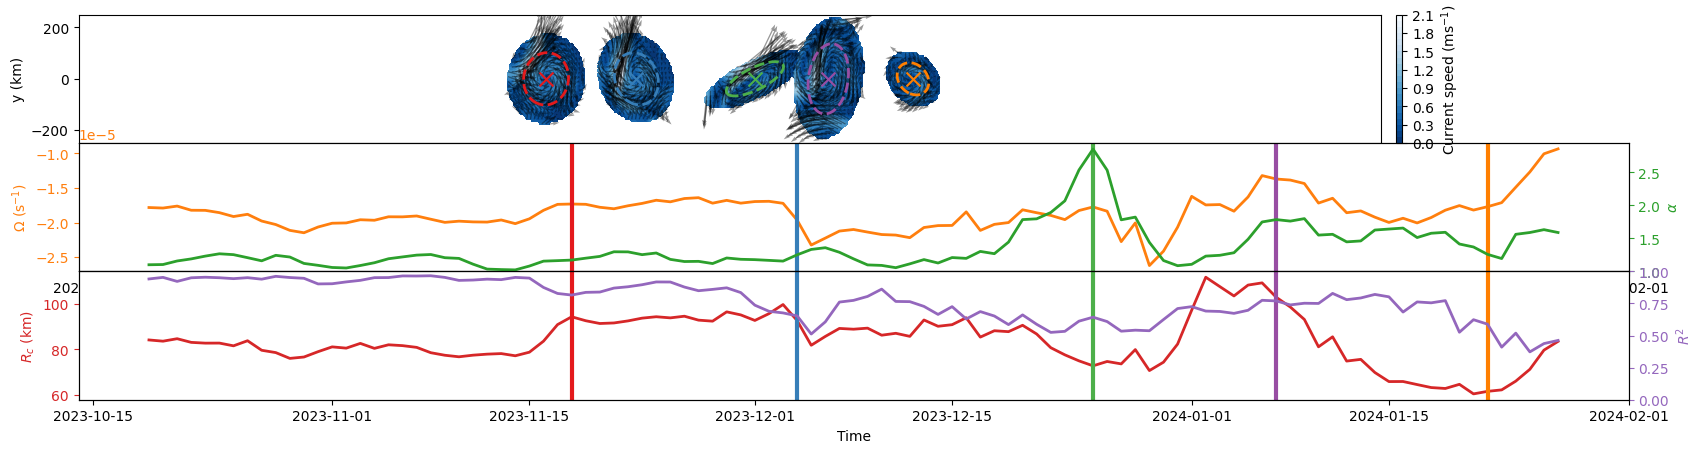

In [381]:
# base grid in km
Xg = cop.x.values / 1e3
Yg = cop.y.values / 1e3


tstamps = [30, 46, 67, 80, 95]
ks = tstamps
rho_outer_thresh = 180  # km

ny, nx = Xg.shape

dx_big = np.diff(Xg, axis=1).mean()
dy_big = np.diff(Yg, axis=0).mean()

x_big = np.arange(-200, 2000, dx_big)
y_big = np.arange(-250, 250, dy_big)

X_big, Y_big = np.meshgrid(x_big, y_big)

U_big = np.full(X_big.shape, np.nan)
V_big = np.full(X_big.shape, np.nan)

# x_offsets = x_big[round(np.array(tstamps)/len(df_res)*len(x_big))] # np.arange(len(ks)) * 350
frac = np.array(tstamps) / (len(df_res) - 1)
x_offsets = x_big.min() + frac * (x_big.max() - x_big.min())
y_offset = 0

fig, axs = plt.subplots(3, 1, figsize=(20, 5))
ax = axs[0]
clrs = plt.colormaps['Set1'] # or cmap more different to tab10
for j, k in enumerate(ks):
    data = df_res.iloc[k]
    cop = ds_cop.sel(time=data.time, method="nearest")

    uc = cop.u.values
    vc = cop.v.values

    dx = Xg - data.xc / 1e3
    dy = Yg - data.yc / 1e3

    q11, q12, q22 = data.Q[0, 0], data.Q[0, 1], data.Q[1, 1]
    rho2 = q11 * dx**2 + 2 * q12 * dx * dy + q22 * dy**2

    # mask = rho2 <= rho_outer_thresh**2
    mask = rho2 <= (data.Rc/1e3*1.75)**2

    um = np.where(mask, uc, np.nan)
    vm = np.where(mask, vc, np.nan)

    R_grid = np.hypot(Xg - data.xc / 1e3, Yg - data.yc / 1e3)
    ic, jc = np.unravel_index(np.nanargmin(R_grid), R_grid.shape)

    xc_target = x_offsets[j]
    yc_target = y_offset

    R_big = np.hypot(X_big - xc_target, Y_big - yc_target)
    ib, jb = np.unravel_index(np.nanargmin(R_big), R_big.shape)

    i0 = ib - ic
    i1 = i0 + ny
    j0 = jb - jc
    j1 = j0 + nx

    si0 = max(0, i0)
    sj0 = max(0, j0)
    si1 = min(U_big.shape[0], i1)
    sj1 = min(U_big.shape[1], j1)

    ui0 = si0 - i0
    uj0 = sj0 - j0
    ui1 = ui0 + (si1 - si0)
    uj1 = uj0 + (sj1 - sj0)

    U_sub = U_big[si0:si1, sj0:sj1]
    V_sub = V_big[si0:si1, sj0:sj1]

    u_new = um[ui0:ui1, uj0:uj1]
    v_new = vm[ui0:ui1, uj0:uj1]

    mask_new = np.isfinite(u_new) & np.isfinite(v_new)

    U_sub[mask_new] = u_new[mask_new]
    V_sub[mask_new] = v_new[mask_new]

    U_big[si0:si1, sj0:sj1] = U_sub
    V_big[si0:si1, sj0:sj1] = V_sub

    X_shift = Xg - data.xc / 1e3 + xc_target
    Y_shift = Yg - data.yc / 1e3 + yc_target

    ax.scatter(
        xc_target,
        yc_target,
        marker='x',
        s=100,
        color=clrs(j),
        zorder=5
    )

    ax.contour(
        X_shift,
        Y_shift,
        rho2,
        levels=[(data.Rc / 1e3) ** 2],
        linestyles='--',
        colors=clrs(j),
        linewidths=2
    )

spd_big = np.hypot(U_big, V_big)

cf = ax.contourf(X_big, Y_big, spd_big, levels=20, cmap='Blues_r')

spac = 2
ax.quiver(
    X_big[::spac, ::spac],
    Y_big[::spac, ::spac],
    U_big[::spac, ::spac],
    V_big[::spac, ::spac],
    color='k',
    scale=40,
    width=0.001,
    alpha=.4
)

plt.colorbar(cf, ax=ax, label='Current speed (ms$^{-1}$)', pad=0.01)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.axis('equal')

ax.set_xlim(x_offsets.min() - 150, x_offsets.max() + 150)
ax.set_ylim(y_big.min(), y_big.max())

# parameter plots
clrs2 = plt.colormaps['tab10']
axs = [axs[1], axs[2]]
lw = 2

# ---------------- top panel: Omega + alpha ----------------
axr0 = axs[0].twinx()

axs[0].plot(df_res.time, df_res.Omega, color=clrs2(1), lw=lw)
axr0.plot(df_res.time, df_res.alpha, color=clrs2(2), lw=lw)

axs[0].set_ylabel(r'$\Omega$ (s$^{-1}$)', color=clrs2(1))
axr0.set_ylabel(r'$\alpha$', color=clrs2(2))

axs[0].tick_params(axis='y', colors=clrs2(1))
axr0.tick_params(axis='y', colors=clrs2(2))
axr0.set_ylim(1, None)

# ---------------- bottom panel: Rc + R2 ----------------
axr1 = axs[1].twinx()

axs[1].plot(df_res.time, df_res.Rc/1e3, color=clrs2(3), lw=lw)
axr1.plot(df_res.time, df_res.R2, color=clrs2(4), lw=lw)

axs[1].set_ylabel(r'$R_c$ (km)', color=clrs2(3))
axr1.set_ylabel(r'$R^2$', color=clrs2(4))

axs[1].tick_params(axis='y', colors=clrs2(3))
axr1.tick_params(axis='y', colors=clrs2(4))
axr1.set_ylim(0, 1)

# ---------------- shared x + vertical lines ----------------
axs[1].set_xlabel('Time')

for ax in axs:
    for k, t in enumerate(tstamps):
        ax.axvline(df_res.time.iloc[t], color=clrs(k), lw=3, alpha=1)

# fig.suptitle("DOPPIO - Numerical Analysis")
fig.subplots_adjust(hspace=0)

plt.show()


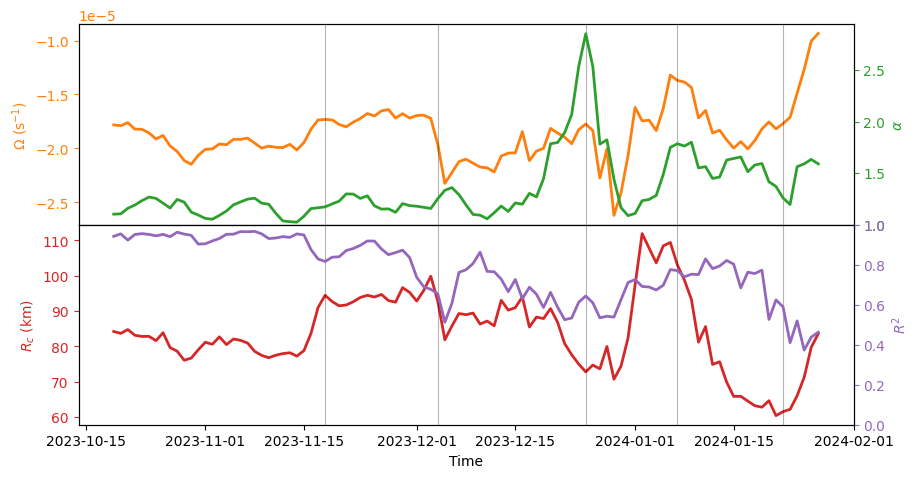

In [367]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)

lw = 2

# ---------------- top panel: Omega + alpha ----------------
axr0 = axs[0].twinx()

axs[0].plot(df_res.time, df_res.Omega, color=clrs(1), lw=lw)
axr0.plot(df_res.time, df_res.alpha, color=clrs(2), lw=lw)

axs[0].set_ylabel(r'$\Omega$ (s$^{-1}$)', color=clrs(1))
axr0.set_ylabel(r'$\alpha$', color=clrs(2))

axs[0].tick_params(axis='y', colors=clrs(1))
axr0.tick_params(axis='y', colors=clrs(2))
axr0.set_ylim(1, None)

# ---------------- bottom panel: Rc + R2 ----------------
axr1 = axs[1].twinx()

axs[1].plot(df_res.time, df_res.Rc/1e3, color=clrs(3), lw=lw)
axr1.plot(df_res.time, df_res.R2, color=clrs(4), lw=lw)

axs[1].set_ylabel(r'$R_c$ (km)', color=clrs(3))
axr1.set_ylabel(r'$R^2$', color=clrs(4))

axs[1].tick_params(axis='y', colors=clrs(3))
axr1.tick_params(axis='y', colors=clrs(4))
axr1.set_ylim(0, 1)

# ---------------- shared x + vertical lines ----------------
axs[1].set_xlabel('Time')

for ax in axs:
    for t in tstamps:
        ax.axvline(df_res.time.iloc[t], color='k', lw=0.8, alpha=0.3)

# fig.suptitle("DOPPIO - Numerical Analysis")
fig.subplots_adjust(hspace=0)



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


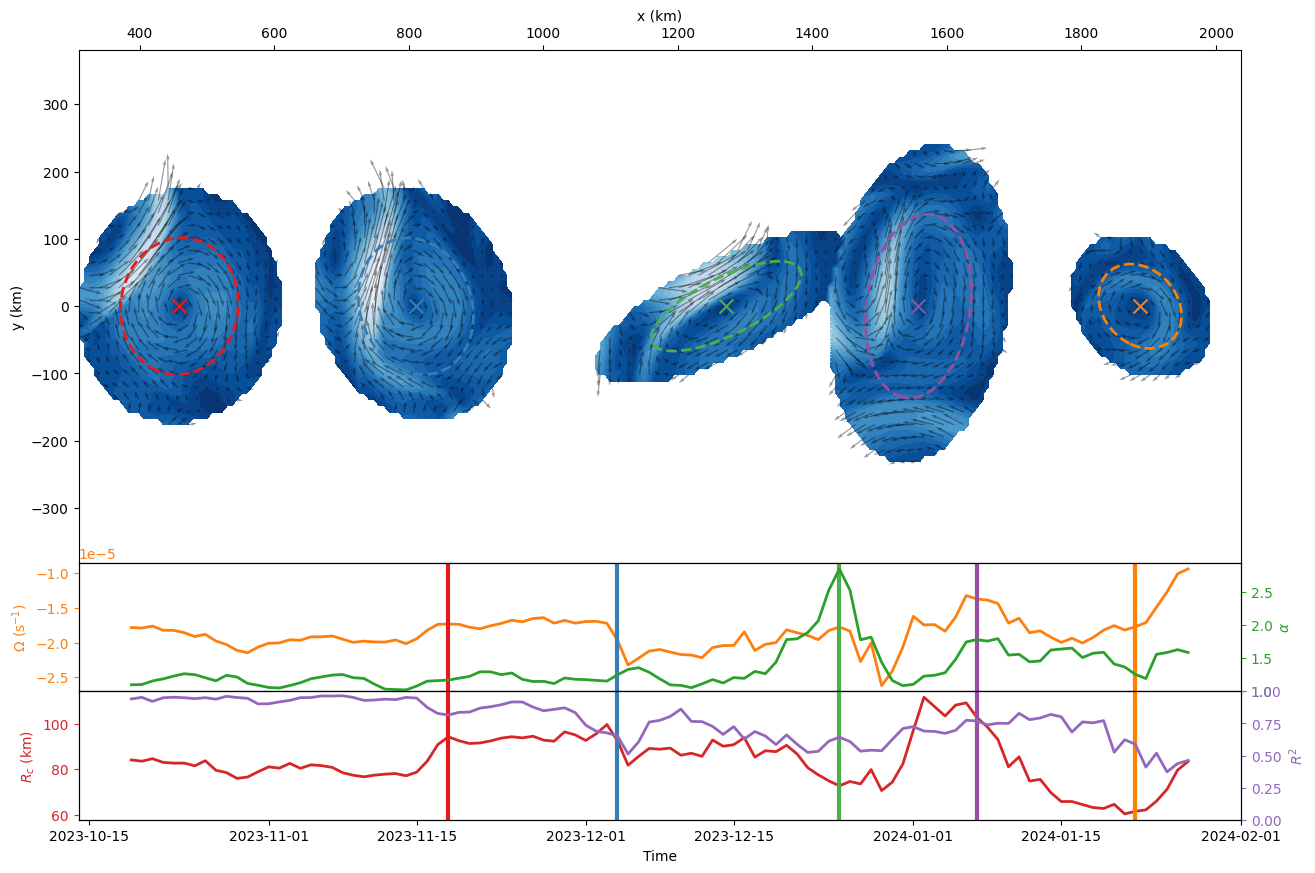

In [395]:
# base grid in km
Xg = cop.x.values / 1e3
Yg = cop.y.values / 1e3

tstamps = [30, 46, 67, 80, 95]
ks = tstamps
rho_outer_thresh = 180  # km

ny, nx = Xg.shape

dx_big = np.diff(Xg, axis=1).mean()
dy_big = np.diff(Yg, axis=0).mean()

x_big = np.arange(-200, 2000, dx_big)
y_big = np.arange(-250, 250, dy_big)

X_big, Y_big = np.meshgrid(x_big, y_big)

U_big = np.full(X_big.shape, np.nan)
V_big = np.full(X_big.shape, np.nan)

# ---------------- time-based x offsets ----------------
time_vals = pd.to_datetime(df_res.time)
time_num = mdates.date2num(time_vals)

sel_time_num = time_num[ks]

x_left = x_big.min()
x_right = x_big.max()

# map actual time onto x positions in the top panel
x_offsets = x_left + (sel_time_num - time_num.min()) / (time_num.max() - time_num.min()) * (x_right - x_left)
y_offset = 0

fig, axs = plt.subplots(
    3, 1,
    figsize=(15, 10),
    gridspec_kw={'height_ratios': [2, .5, .5]}
)

ax_top = axs[0]
ax_mid = axs[1]
ax_bot = axs[2]

clrs = plt.colormaps['Set1']

for j, k in enumerate(ks):
    data = df_res.iloc[k]
    cop = ds_cop.sel(time=data.time, method="nearest")

    uc = cop.u.values
    vc = cop.v.values

    dx = Xg - data.xc / 1e3
    dy = Yg - data.yc / 1e3

    q11, q12, q22 = data.Q[0, 0], data.Q[0, 1], data.Q[1, 1]
    rho2 = q11 * dx**2 + 2 * q12 * dx * dy + q22 * dy**2

    mask = rho2 <= (data.Rc / 1e3 * 1.75) ** 2

    um = np.where(mask, uc, np.nan)
    vm = np.where(mask, vc, np.nan)

    R_grid = np.hypot(Xg - data.xc / 1e3, Yg - data.yc / 1e3)
    ic, jc = np.unravel_index(np.nanargmin(R_grid), R_grid.shape)

    xc_target = x_offsets[j]
    yc_target = y_offset

    R_big = np.hypot(X_big - xc_target, Y_big - yc_target)
    ib, jb = np.unravel_index(np.nanargmin(R_big), R_big.shape)

    i0 = ib - ic
    i1 = i0 + ny
    j0 = jb - jc
    j1 = j0 + nx

    si0 = max(0, i0)
    sj0 = max(0, j0)
    si1 = min(U_big.shape[0], i1)
    sj1 = min(U_big.shape[1], j1)

    ui0 = si0 - i0
    uj0 = sj0 - j0
    ui1 = ui0 + (si1 - si0)
    uj1 = uj0 + (sj1 - sj0)

    U_sub = U_big[si0:si1, sj0:sj1]
    V_sub = V_big[si0:si1, sj0:sj1]

    u_new = um[ui0:ui1, uj0:uj1]
    v_new = vm[ui0:ui1, uj0:uj1]

    mask_new = np.isfinite(u_new) & np.isfinite(v_new)

    U_sub[mask_new] = u_new[mask_new]
    V_sub[mask_new] = v_new[mask_new]

    U_big[si0:si1, sj0:sj1] = U_sub
    V_big[si0:si1, sj0:sj1] = V_sub

    X_shift = Xg - data.xc / 1e3 + xc_target
    Y_shift = Yg - data.yc / 1e3 + yc_target

    ax_top.scatter(
        xc_target,
        yc_target,
        marker='x',
        s=100,
        color=clrs(j),
        zorder=5
    )

    ax_top.contour(
        X_shift,
        Y_shift,
        rho2,
        levels=[(data.Rc / 1e3) ** 2],
        linestyles='--',
        colors=clrs(j),
        linewidths=2
    )

spd_big = np.hypot(U_big, V_big)

cf = ax_top.contourf(X_big, Y_big, spd_big, levels=20, cmap='Blues_r')

spac = 2
ax_top.quiver(
    X_big[::spac, ::spac],
    Y_big[::spac, ::spac],
    U_big[::spac, ::spac],
    V_big[::spac, ::spac],
    color='k',
    scale=40,
    width=0.001,
    alpha=.4
)

ax_top.set_xlabel('x (km)')
ax_top.set_ylabel('y (km)')
ax_top.axis('equal')
ax_top.set_xlim(x_offsets.min() - 150, x_offsets.max() + 150)
ax_top.set_ylim(y_big.min(), y_big.max())
ax_top.xaxis.set_ticks_position('top')
ax_top.xaxis.set_label_position('top')

# ---------------- middle panel: Omega + alpha ----------------
clrs2 = plt.colormaps['tab10']
lw = 2

ax_mid_r = ax_mid.twinx()

ax_mid.plot(time_vals, df_res.Omega, color=clrs2(1), lw=lw)
ax_mid_r.plot(time_vals, df_res.alpha, color=clrs2(2), lw=lw)

ax_mid.set_ylabel(r'$\Omega$ (s$^{-1}$)', color=clrs2(1))
ax_mid_r.set_ylabel(r'$\alpha$', color=clrs2(2))

ax_mid.tick_params(axis='y', colors=clrs2(1))
ax_mid_r.tick_params(axis='y', colors=clrs2(2))
ax_mid_r.set_ylim(1, None)
ax_mid.tick_params(axis='x', labelbottom=False)

# ---------------- bottom panel: Rc + R2 ----------------
ax_bot_r = ax_bot.twinx()

ax_bot.plot(time_vals, df_res.Rc / 1e3, color=clrs2(3), lw=lw)
ax_bot_r.plot(time_vals, df_res.R2, color=clrs2(4), lw=lw)

ax_bot.set_ylabel(r'$R_c$ (km)', color=clrs2(3))
ax_bot_r.set_ylabel(r'$R^2$', color=clrs2(4))

ax_bot.tick_params(axis='y', colors=clrs2(3))
ax_bot_r.tick_params(axis='y', colors=clrs2(4))
ax_bot_r.set_ylim(0, 1)
ax_bot.set_xlabel('Time')

# ---------------- vertical lines ----------------
for ax_ in [ax_mid, ax_bot]:
    for k, t in enumerate(ks):
        ax_.axvline(time_vals.iloc[t], color=clrs(k), lw=3, alpha=1)

fig.subplots_adjust(hspace=0)
plt.show()




Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


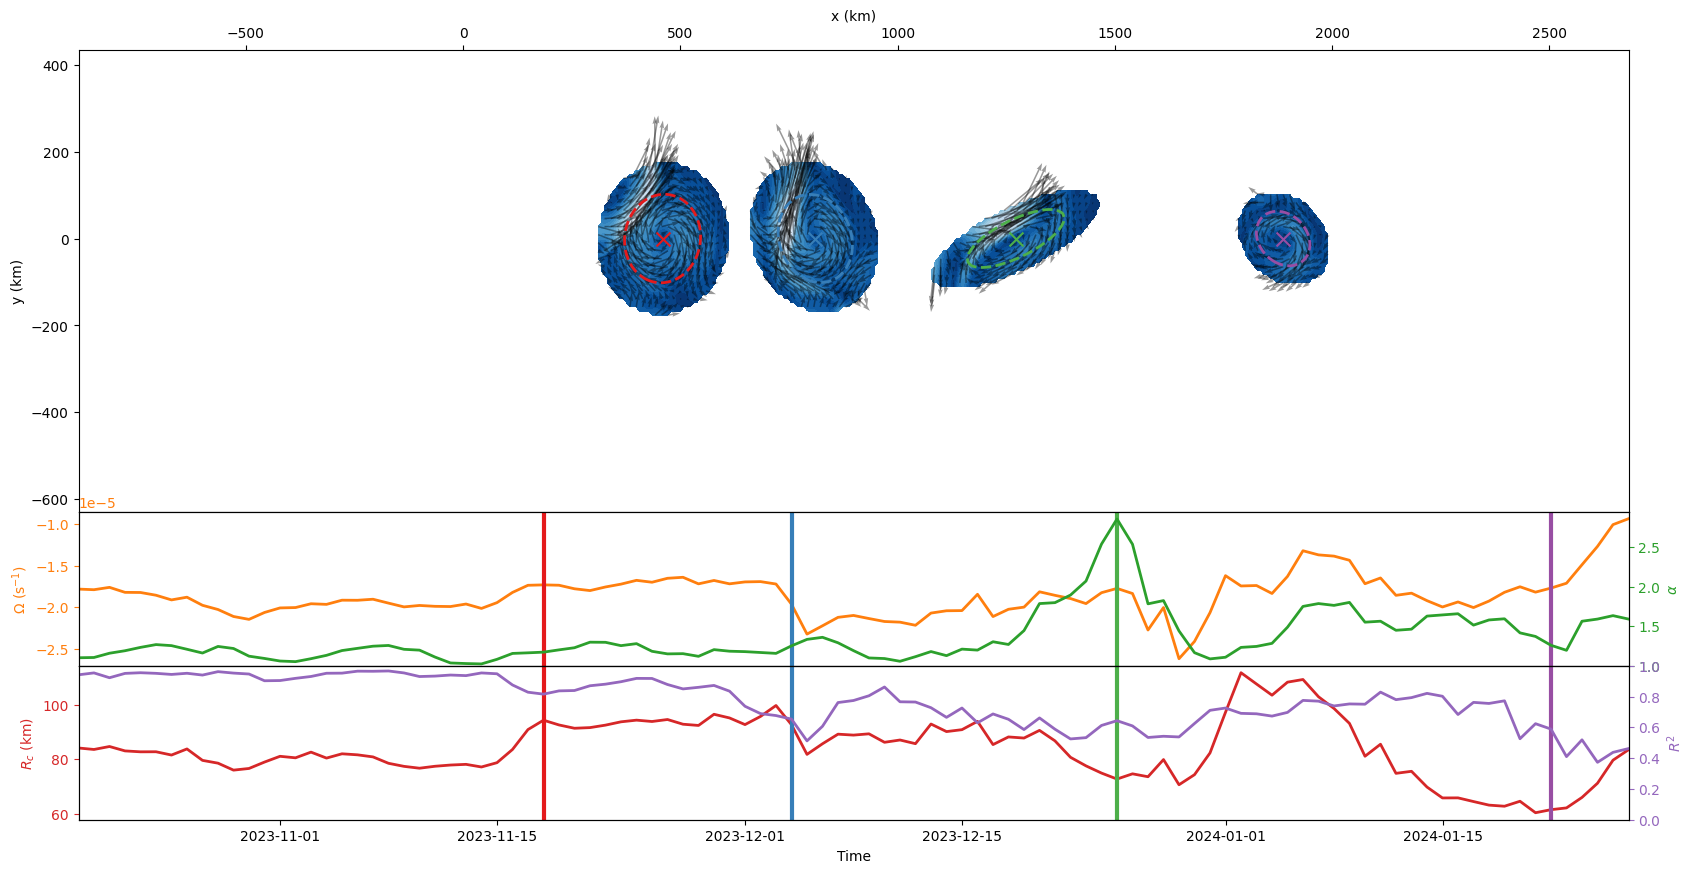

In [404]:
# base grid in km
Xg = cop.x.values / 1e3
Yg = cop.y.values / 1e3

tstamps = [30, 46, 67, 95]
ks = tstamps
rho_outer_thresh = 180  # km

ny, nx = Xg.shape

dx_big = np.diff(Xg, axis=1).mean()
dy_big = np.diff(Yg, axis=0).mean()

x_big = np.arange(-200, 2000, dx_big)
y_big = np.arange(-250, 250, dy_big)

X_big, Y_big = np.meshgrid(x_big, y_big)

U_big = np.full(X_big.shape, np.nan)
V_big = np.full(X_big.shape, np.nan)

# ---------------- time-based x offsets ----------------
time_vals = pd.to_datetime(df_res.time)
time_num = mdates.date2num(time_vals)

sel_time_num = time_num[ks]

x_left = x_big.min()
x_right = x_big.max()

# map full time range onto full top-panel x range
x_offsets = x_left + (sel_time_num - time_num.min()) / (time_num.max() - time_num.min()) * (x_right - x_left)
y_offset = 0

fig, axs = plt.subplots(
    3, 1,
    figsize=(20, 10),
    gridspec_kw={'height_ratios': [1.5, 0.5, 0.5]}
)

ax_top = axs[0]
ax_mid = axs[1]
ax_bot = axs[2]

clrs = plt.colormaps['Set1']

for j, k in enumerate(ks):
    data = df_res.iloc[k]
    cop = ds_cop.sel(time=data.time, method="nearest")

    uc = cop.u.values
    vc = cop.v.values

    dx = Xg - data.xc / 1e3
    dy = Yg - data.yc / 1e3

    q11, q12, q22 = data.Q[0, 0], data.Q[0, 1], data.Q[1, 1]
    rho2 = q11 * dx**2 + 2 * q12 * dx * dy + q22 * dy**2

    mask = rho2 <= (data.Rc / 1e3 * 1.75) ** 2

    um = np.where(mask, uc, np.nan)
    vm = np.where(mask, vc, np.nan)

    R_grid = np.hypot(Xg - data.xc / 1e3, Yg - data.yc / 1e3)
    ic, jc = np.unravel_index(np.nanargmin(R_grid), R_grid.shape)

    xc_target = x_offsets[j]
    yc_target = y_offset

    R_big = np.hypot(X_big - xc_target, Y_big - yc_target)
    ib, jb = np.unravel_index(np.nanargmin(R_big), R_big.shape)

    i0 = ib - ic
    i1 = i0 + ny
    j0 = jb - jc
    j1 = j0 + nx

    si0 = max(0, i0)
    sj0 = max(0, j0)
    si1 = min(U_big.shape[0], i1)
    sj1 = min(U_big.shape[1], j1)

    ui0 = si0 - i0
    uj0 = sj0 - j0
    ui1 = ui0 + (si1 - si0)
    uj1 = uj0 + (sj1 - sj0)

    U_sub = U_big[si0:si1, sj0:sj1]
    V_sub = V_big[si0:si1, sj0:sj1]

    u_new = um[ui0:ui1, uj0:uj1]
    v_new = vm[ui0:ui1, uj0:uj1]

    mask_new = np.isfinite(u_new) & np.isfinite(v_new)

    U_sub[mask_new] = u_new[mask_new]
    V_sub[mask_new] = v_new[mask_new]

    U_big[si0:si1, sj0:sj1] = U_sub
    V_big[si0:si1, sj0:sj1] = V_sub

    X_shift = Xg - data.xc / 1e3 + xc_target
    Y_shift = Yg - data.yc / 1e3 + yc_target

    ax_top.scatter(
        xc_target,
        yc_target,
        marker='x',
        s=100,
        color=clrs(j),
        zorder=5
    )

    ax_top.contour(
        X_shift,
        Y_shift,
        rho2,
        levels=[(data.Rc / 1e3) ** 2],
        linestyles='--',
        colors=clrs(j),
        linewidths=2
    )

spd_big = np.hypot(U_big, V_big)

cf = ax_top.contourf(X_big, Y_big, spd_big, levels=20, cmap='Blues_r')

spac = 2
ax_top.quiver(
    X_big[::spac, ::spac],
    Y_big[::spac, ::spac],
    U_big[::spac, ::spac],
    V_big[::spac, ::spac],
    color='k',
    scale=40,
    width=0.001,
    alpha=.4
)

ax_top.set_xlabel('x (km)')
ax_top.set_ylabel('y (km)')
ax_top.set_ylim(y_big.min(), y_big.max())
ax_top.axis('equal')

# crucial: use full x-range, not a cropped range based on selected offsets
ax_top.set_xlim(x_left, x_right)

ax_top.xaxis.set_ticks_position('top')
ax_top.xaxis.set_label_position('top')

# ---------------- middle panel: Omega + alpha ----------------
clrs2 = plt.colormaps['tab10']
lw = 2

ax_mid_r = ax_mid.twinx()

ax_mid.plot(time_vals, df_res.Omega, color=clrs2(1), lw=lw)
ax_mid_r.plot(time_vals, df_res.alpha, color=clrs2(2), lw=lw)

ax_mid.set_ylabel(r'$\Omega$ (s$^{-1}$)', color=clrs2(1))
ax_mid_r.set_ylabel(r'$\alpha$', color=clrs2(2))

ax_mid.tick_params(axis='y', colors=clrs2(1))
ax_mid_r.tick_params(axis='y', colors=clrs2(2))
ax_mid_r.set_ylim(1, None)
ax_mid.tick_params(axis='x', labelbottom=False)

# ---------------- bottom panel: Rc + R2 ----------------
ax_bot_r = ax_bot.twinx()

ax_bot.plot(time_vals, df_res.Rc / 1e3, color=clrs2(3), lw=lw)
ax_bot_r.plot(time_vals, df_res.R2, color=clrs2(4), lw=lw)

ax_bot.set_ylabel(r'$R_c$ (km)', color=clrs2(3))
ax_bot_r.set_ylabel(r'$R^2$', color=clrs2(4))

ax_bot.tick_params(axis='y', colors=clrs2(3))
ax_bot_r.tick_params(axis='y', colors=clrs2(4))
ax_bot_r.set_ylim(0, 1)
ax_bot.set_xlabel('Time')

# make bottom panels span the full same time range
ax_mid.set_xlim(time_vals.min(), time_vals.max())
ax_bot.set_xlim(time_vals.min(), time_vals.max())

# ---------------- vertical lines ----------------
for ax_ in [ax_mid, ax_bot]:
    for k, t in enumerate(ks):
        ax_.axvline(time_vals.iloc[t], color=clrs(k), lw=3, alpha=1)

fig.subplots_adjust(hspace=0)
plt.show()






Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


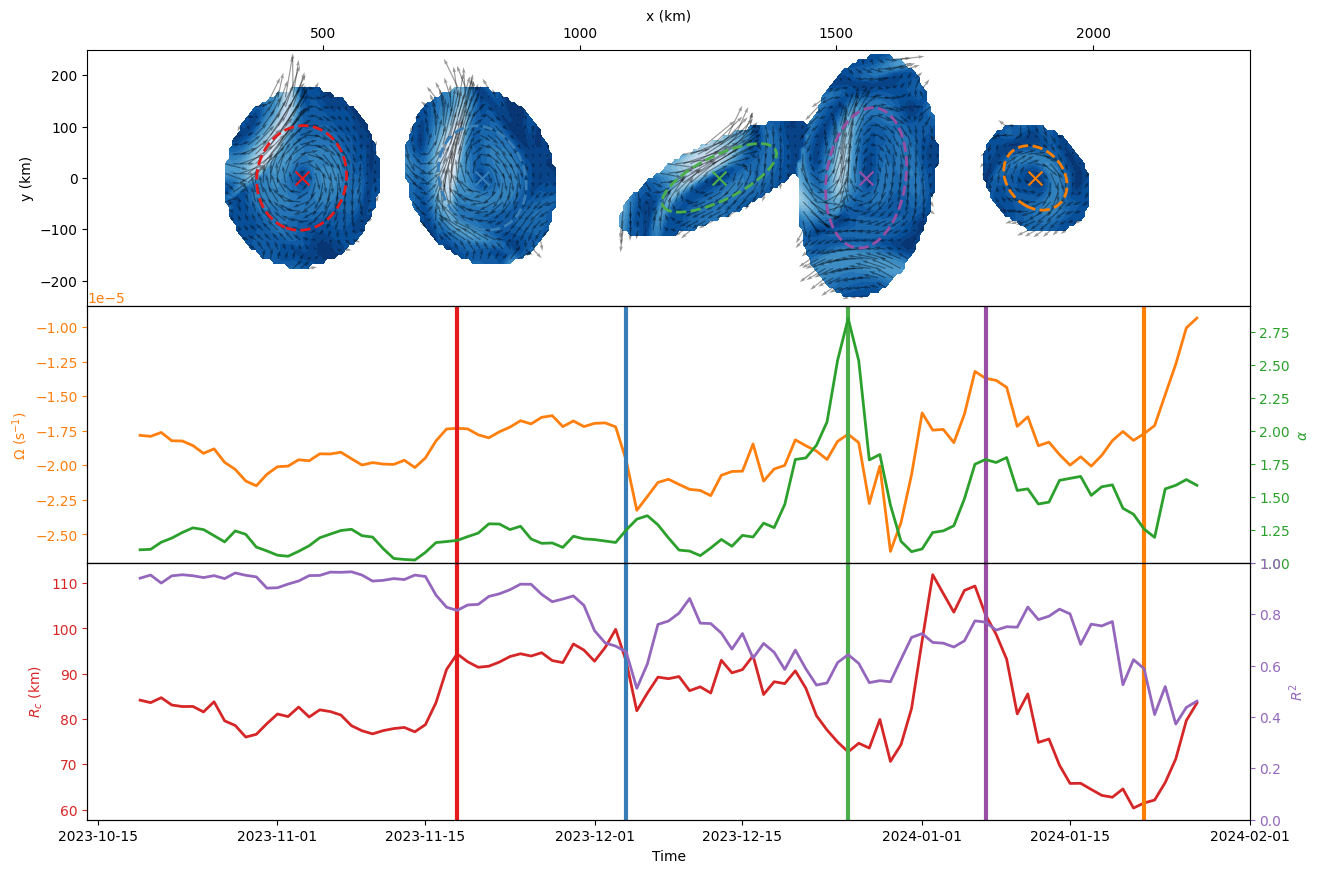

In [391]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# base grid in km
Xg = cop.x.values / 1e3
Yg = cop.y.values / 1e3

tstamps = [30, 46, 67, 80, 95]
ks = tstamps
rho_outer_thresh = 180  # km

ny, nx = Xg.shape

dx_big = np.diff(Xg, axis=1).mean()
dy_big = np.diff(Yg, axis=0).mean()

x_big = np.arange(-200, 2000, dx_big)
y_big = np.arange(-250, 250, dy_big)

X_big, Y_big = np.meshgrid(x_big, y_big)

U_big = np.full(X_big.shape, np.nan)
V_big = np.full(X_big.shape, np.nan)

# ---------------- time-based x offsets ----------------
time_vals = pd.to_datetime(df_res.time)
time_num = mdates.date2num(time_vals)

sel_time_num = time_num[ks]

x_left = x_big.min()
x_right = x_big.max()

# map actual time onto x positions in the top panel
x_offsets = x_left + (sel_time_num - time_num.min()) / (time_num.max() - time_num.min()) * (x_right - x_left)
y_offset = 0

fig, axs = plt.subplots(3, 1, figsize=(15, 10))
ax = axs[0]
clrs = plt.colormaps['Set1']

for j, k in enumerate(ks):
    data = df_res.iloc[k]
    cop = ds_cop.sel(time=data.time, method="nearest")

    uc = cop.u.values
    vc = cop.v.values

    dx = Xg - data.xc / 1e3
    dy = Yg - data.yc / 1e3

    q11, q12, q22 = data.Q[0, 0], data.Q[0, 1], data.Q[1, 1]
    rho2 = q11 * dx**2 + 2 * q12 * dx * dy + q22 * dy**2

    mask = rho2 <= (data.Rc / 1e3 * 1.75) ** 2

    um = np.where(mask, uc, np.nan)
    vm = np.where(mask, vc, np.nan)

    R_grid = np.hypot(Xg - data.xc / 1e3, Yg - data.yc / 1e3)
    ic, jc = np.unravel_index(np.nanargmin(R_grid), R_grid.shape)

    xc_target = x_offsets[j]
    yc_target = y_offset

    R_big = np.hypot(X_big - xc_target, Y_big - yc_target)
    ib, jb = np.unravel_index(np.nanargmin(R_big), R_big.shape)

    i0 = ib - ic
    i1 = i0 + ny
    j0 = jb - jc
    j1 = j0 + nx

    si0 = max(0, i0)
    sj0 = max(0, j0)
    si1 = min(U_big.shape[0], i1)
    sj1 = min(U_big.shape[1], j1)

    ui0 = si0 - i0
    uj0 = sj0 - j0
    ui1 = ui0 + (si1 - si0)
    uj1 = uj0 + (sj1 - sj0)

    U_sub = U_big[si0:si1, sj0:sj1]
    V_sub = V_big[si0:si1, sj0:sj1]

    u_new = um[ui0:ui1, uj0:uj1]
    v_new = vm[ui0:ui1, uj0:uj1]

    mask_new = np.isfinite(u_new) & np.isfinite(v_new)

    U_sub[mask_new] = u_new[mask_new]
    V_sub[mask_new] = v_new[mask_new]

    U_big[si0:si1, sj0:sj1] = U_sub
    V_big[si0:si1, sj0:sj1] = V_sub

    X_shift = Xg - data.xc / 1e3 + xc_target
    Y_shift = Yg - data.yc / 1e3 + yc_target

    ax.scatter(
        xc_target,
        yc_target,
        marker='x',
        s=100,
        color=clrs(j),
        zorder=5
    )

    ax.contour(
        X_shift,
        Y_shift,
        rho2,
        levels=[(data.Rc / 1e3) ** 2],
        linestyles='--',
        colors=clrs(j),
        linewidths=2
    )

spd_big = np.hypot(U_big, V_big)

cf = ax.contourf(X_big, Y_big, spd_big, levels=20, cmap='Blues_r')

spac = 2
ax.quiver(
    X_big[::spac, ::spac],
    Y_big[::spac, ::spac],
    U_big[::spac, ::spac],
    V_big[::spac, ::spac],
    color='k',
    scale=40,
    width=0.001,
    alpha=.4
)

# plt.colorbar(cf, ax=ax, label='Current speed (ms$^{-1}$)', pad=0.01)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.axis('equal')

ax.set_xlim(x_offsets.min() - 150, x_offsets.max() + 150)
ax.set_ylim(y_big.min(), y_big.max())

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# parameter plots
clrs2 = plt.colormaps['tab10']
axs = [axs[1], axs[2]]
lw = 2

# ---------------- middle panel: Omega + alpha ----------------
axr0 = axs[0].twinx()

axs[0].plot(time_vals, df_res.Omega, color=clrs2(1), lw=lw)
axr0.plot(time_vals, df_res.alpha, color=clrs2(2), lw=lw)

axs[0].set_ylabel(r'$\Omega$ (s$^{-1}$)', color=clrs2(1))
axr0.set_ylabel(r'$\alpha$', color=clrs2(2))

axs[0].tick_params(axis='y', colors=clrs2(1))
axr0.tick_params(axis='y', colors=clrs2(2))
axr0.set_ylim(1, None)
axr0.set_xticklabels([])

# ---------------- bottom panel: Rc + R2 ----------------
axr1 = axs[1].twinx()

axs[1].plot(time_vals, df_res.Rc / 1e3, color=clrs2(3), lw=lw)
axr1.plot(time_vals, df_res.R2, color=clrs2(4), lw=lw)

axs[1].set_ylabel(r'$R_c$ (km)', color=clrs2(3))
axr1.set_ylabel(r'$R^2$', color=clrs2(4))

axs[1].tick_params(axis='y', colors=clrs2(3))
axr1.tick_params(axis='y', colors=clrs2(4))
axr1.set_ylim(0, 1)

# ---------------- shared x + vertical lines ----------------
axs[1].set_xlabel('Time')

for ax_ in axs:
    for k, t in enumerate(ks):
        ax_.axvline(time_vals.iloc[t], color=clrs(k), lw=3, alpha=1)

fig.subplots_adjust(hspace=0)
plt.show()


In [20]:
df_res.to_pickle('df_res_doppio_num.pkl')


### Animation

In [21]:
# import os

# def save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_drifter_animation",
#     spac=2, scale=20, xlim=(-410, 200), ylim=(-160, 260),
#     out_thresh=False, plot_data=False, vmax=1.2
# ):
#     os.makedirs(outdir, exist_ok=True)

#     frame_paths = []

#     for t_idx in range(len(df_res)):
#         data = df_res.iloc[t_idx]
#         time = data.time

#         sat = ds_cop.sel(time=time, method="nearest")
#         mod = ds_model.sel(time=time, method="nearest")

#         X = sat.x.values / 1e3
#         Y = sat.y.values / 1e3

#         us, vs = sat.u.values, sat.v.values
#         um, vm = mod.u.values, mod.v.values

#         sp_s = np.hypot(us, vs)
#         sp_m = np.hypot(um, vm)

#         dx = sat.x.values - data.xc
#         dy = sat.y.values - data.yc
#         q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
#         rho2_grid = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
#         sp_s_roi = np.where(roi, sp_s, np.nan)
#         sp_m_roi = np.where(roi, sp_m, np.nan)
#         roi_quiv = roi & (rho2_grid >= 100_000**2)

#         vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
#         # vmax = np.nanmax(vals)
#         levels = np.arange(0, vmax + 0.05, 0.05)

#         x_rho = np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100)
#         y_rho = np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100)
#         X_rho, Y_rho = np.meshgrid(x_rho, y_rho)

#         dx = X_rho - data.xc
#         dy = Y_rho - data.yc
#         rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

#         # ---- Numerical model ----
#         h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")
#         axs[0].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
#             np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.4
#         )
#         axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
#         axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)

#         if plot_data:
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "outer")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color="g", label="Outer-core data")
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "inner")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color="m", label="Core data")

#         axs[0].set_title("Numerical Model")
#         axs[0].set_aspect("equal")
#         axs[0].legend(loc="lower left")

#         # ---- Fitted model ----
#         h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
#         axs[1].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
#             np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.5
#         )
#         axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label="Eddy center")
#         axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color="r", label="Max tangential\nvelocity", ls="--")
#         axs[1].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5, label="Center path")
#         axs[1].set_title("Model - DOPPIO with Numerical Data")
#         axs[1].set_aspect("equal")
#         axs[1].legend(loc="lower left")

#         gap = 20
#         for ax in axs:
#             ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
#             ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
#             ax.set_xlabel("x (km)")
#         axs[0].set_ylabel("y (km)")

#         axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
#         axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

#         fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)
#         fig.suptitle(f"{time}")

#         frame_path = os.path.join(outdir, f"frame_{t_idx:03d}.png")
#         fig.savefig(frame_path, dpi=250, bbox_inches="tight")
#         plt.close(fig)
#         frame_paths.append(frame_path)

#     return 
    

In [22]:
# save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_num_animation",
#     out_thresh=False, plot_data=True
# )
